In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing and modeling
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score,
    classification_report, make_scorer
)

train_path = '/content/drive/MyDrive/train_dataset_final1.csv'
val_path = '/content/drive/MyDrive/validate_dataset_final.csv'

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)


Train shape: (25247, 27)
Validation shape: (5016, 26)


In [35]:
# Check for missing values and datatypes
print(train_df.isnull().sum())
print(val_df.isnull().sum())
print(train_df.dtypes)
print(val_df.dtypes)

Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64
Customer_ID          0
marriage             0
sex                  0
education            0
LIMIT_BAL            0
age                  0
pay_0                0
pay_2                0
pay_3                0
pay_4                0
pay_5                0
pay_6                0
Bill_amt1

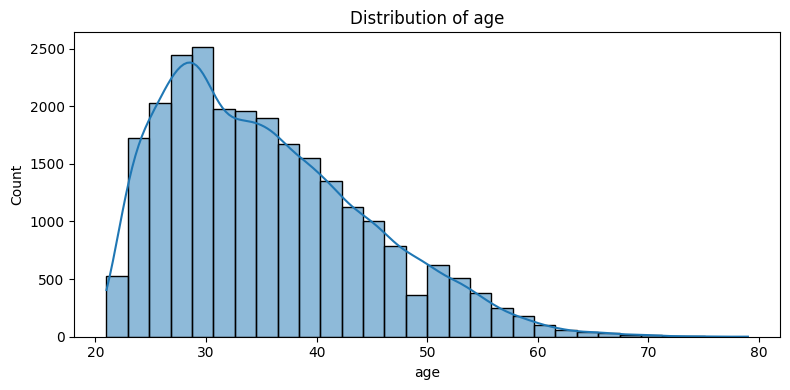

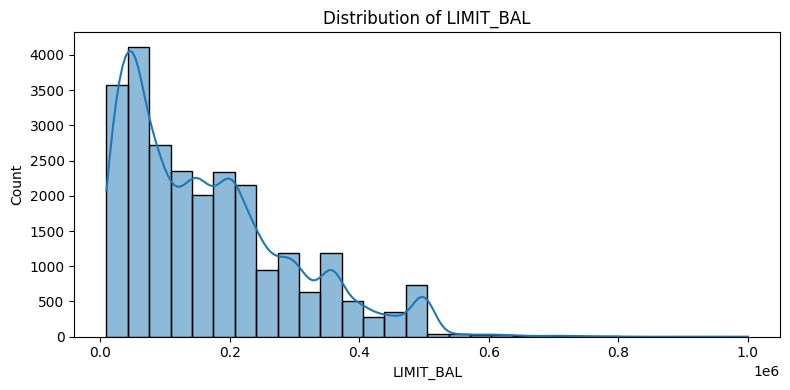

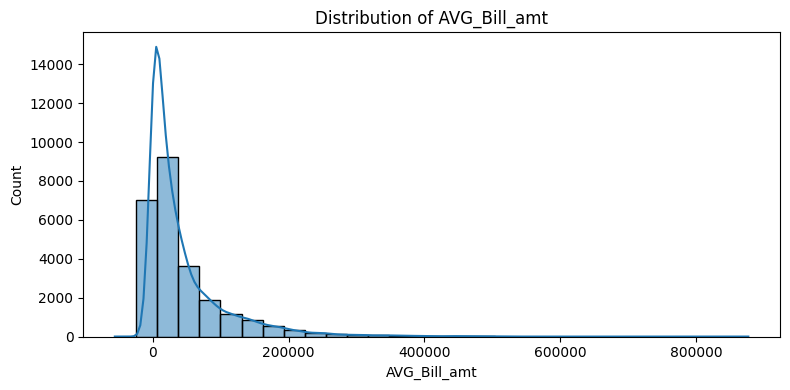

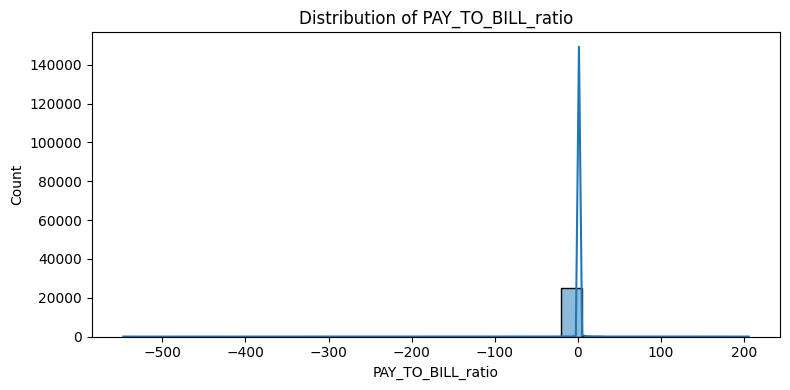

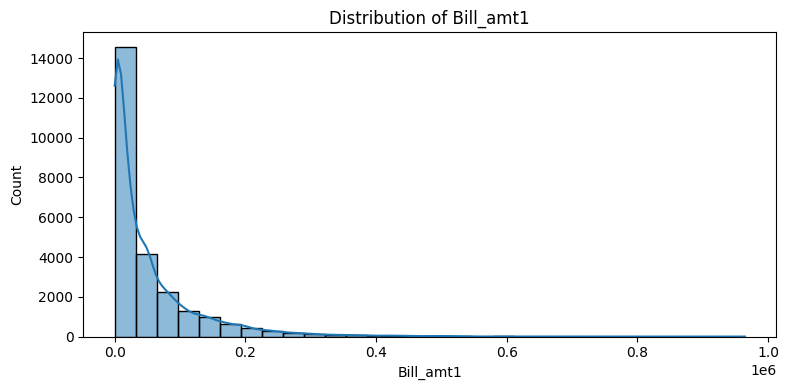

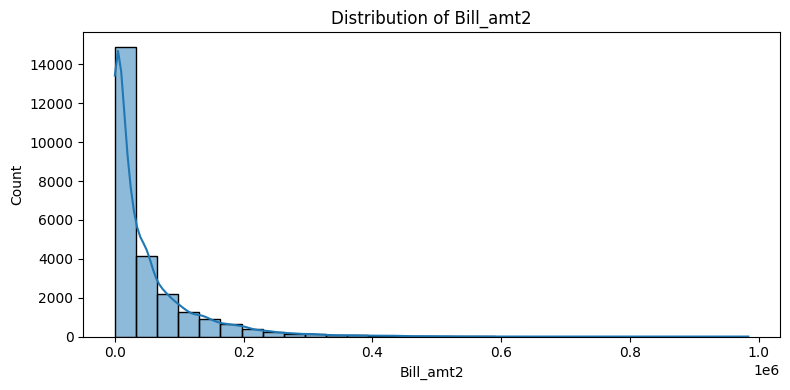

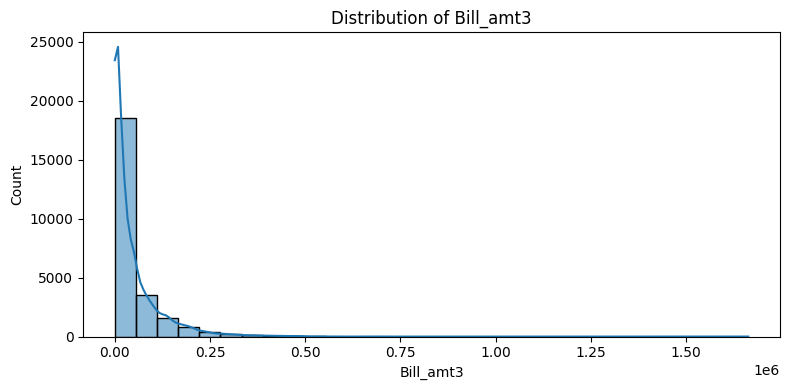

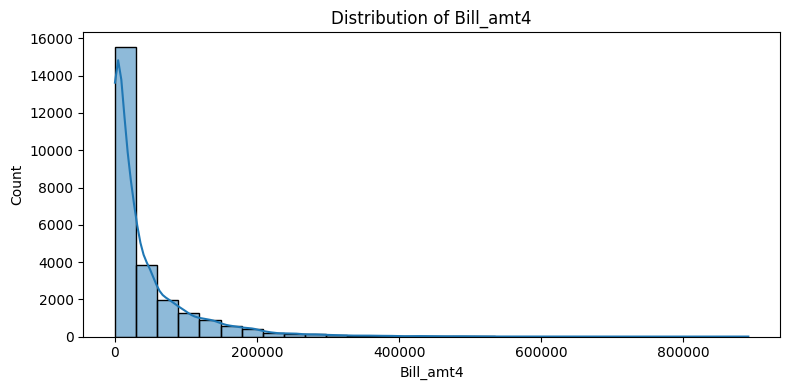

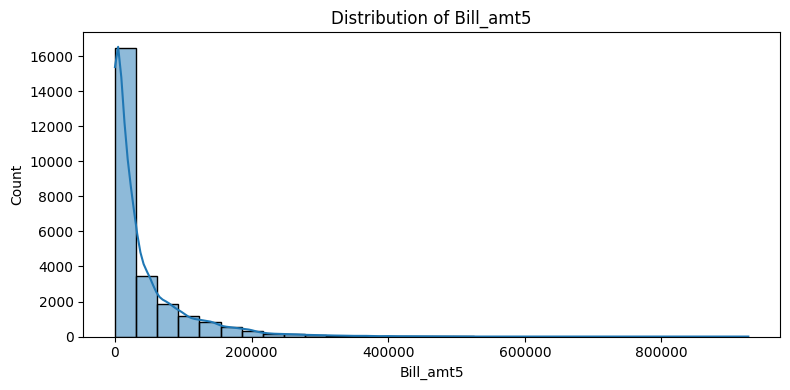

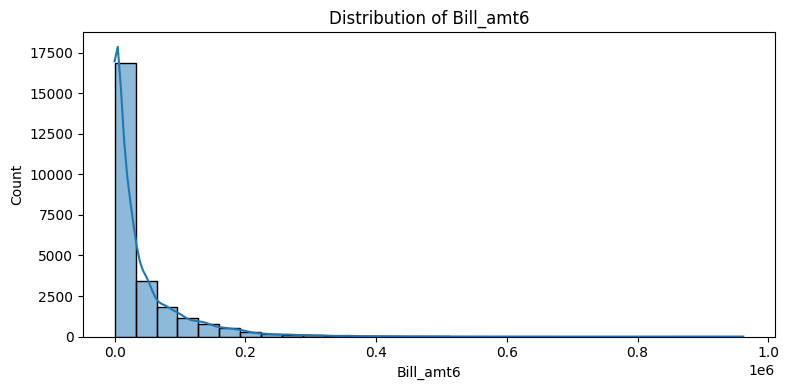

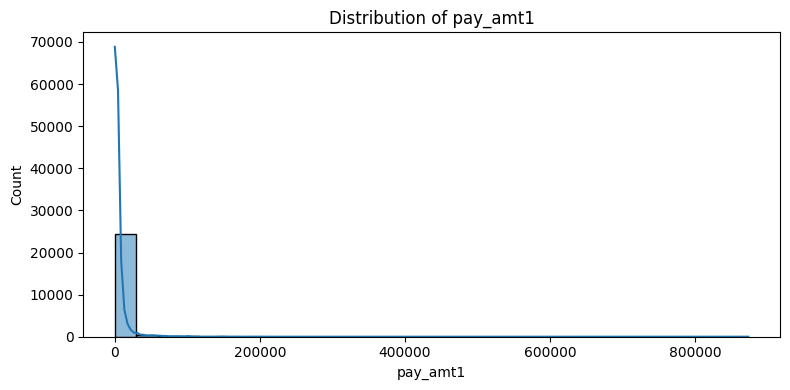

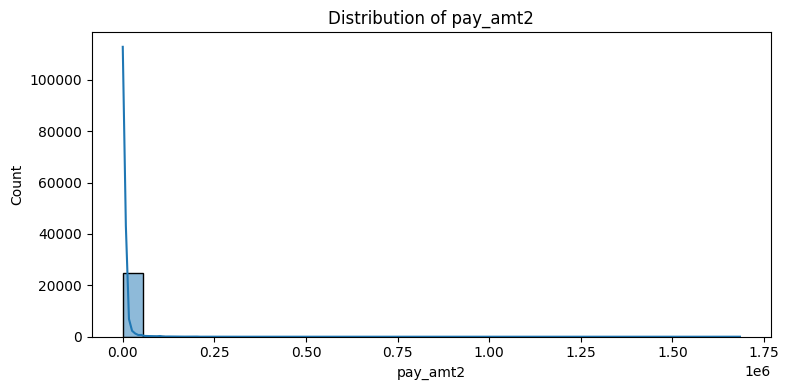

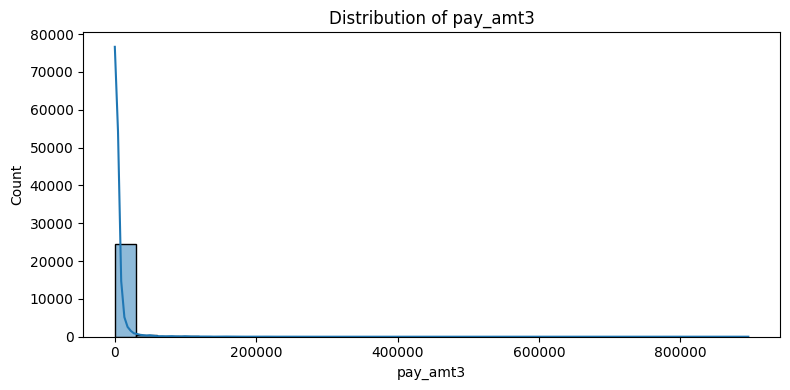

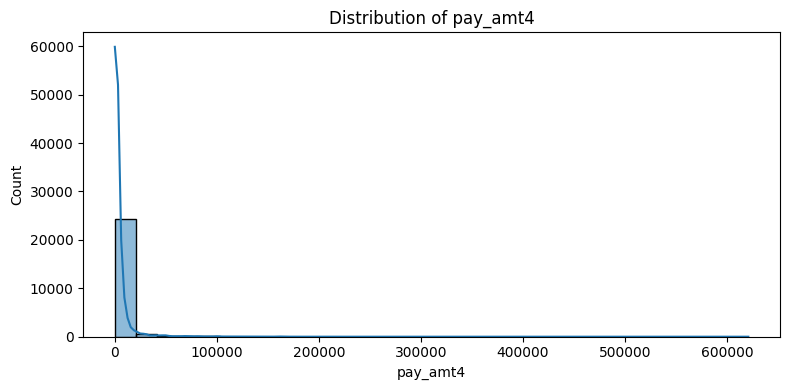

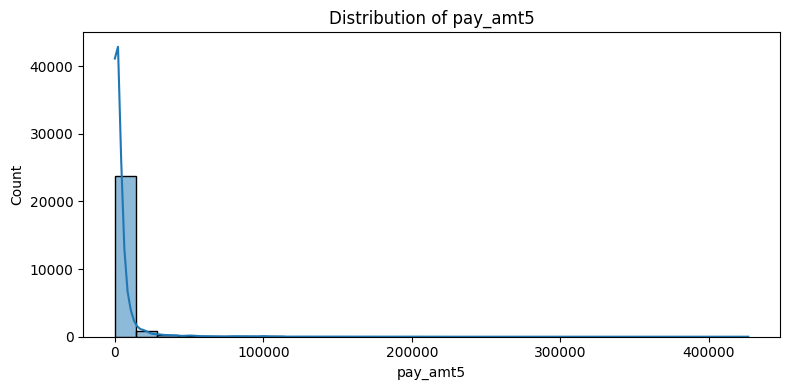

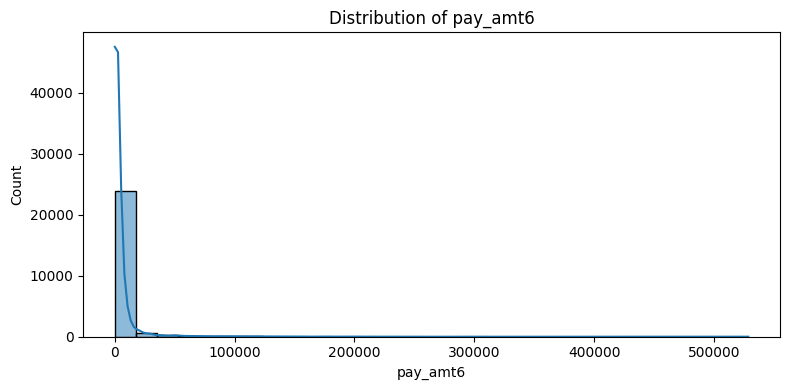

In [36]:
# Univariate analysis for numeric features
numeric_cols = [
    'age', 'LIMIT_BAL', 'AVG_Bill_amt', 'PAY_TO_BILL_ratio',
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6'
]
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

<ipython-input-37-2803105144>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=train_df, palette='pastel')


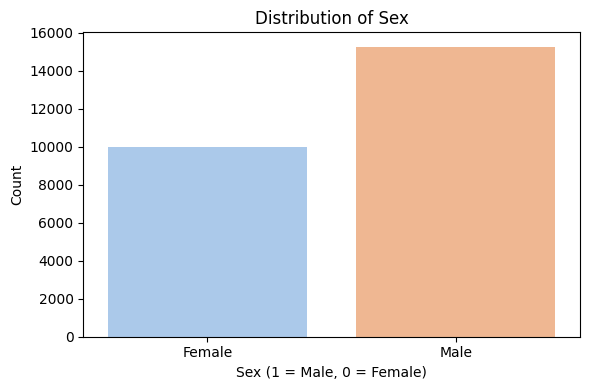

<ipython-input-37-2803105144>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education', data=train_df, palette='pastel')


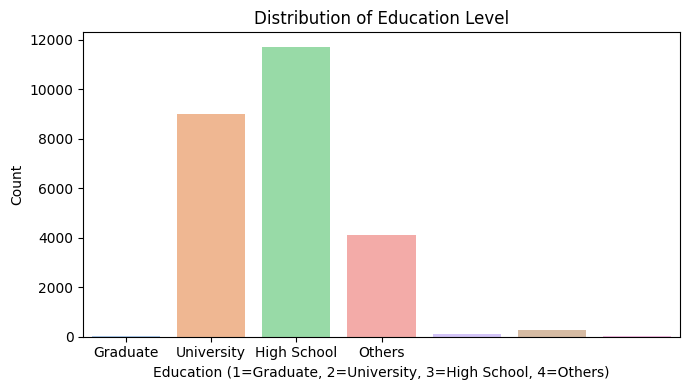

<ipython-input-37-2803105144>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='marriage', data=train_df, palette='pastel')


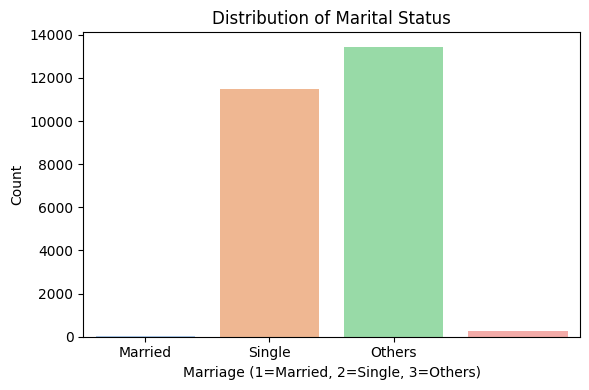

In [37]:
# Bar plot for 'sex'
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=train_df, palette='pastel')
plt.title('Distribution of Sex')
plt.xlabel('Sex (1 = Male, 0 = Female)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.show()

# Bar plot for 'education'
plt.figure(figsize=(7,4))
sns.countplot(x='education', data=train_df, palette='pastel')
plt.title('Distribution of Education Level')
plt.xlabel('Education (1=Graduate, 2=University, 3=High School, 4=Others)')
plt.ylabel('Count')
plt.xticks([0, 1, 2, 3], ['Graduate', 'University', 'High School', 'Others'])
plt.tight_layout()
plt.show()

# Bar plot for 'marriage'
plt.figure(figsize=(6,4))
sns.countplot(x='marriage', data=train_df, palette='pastel')
plt.title('Distribution of Marital Status')
plt.xlabel('Marriage (1=Married, 2=Single, 3=Others)')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Married', 'Single', 'Others'])
plt.tight_layout()
plt.show()


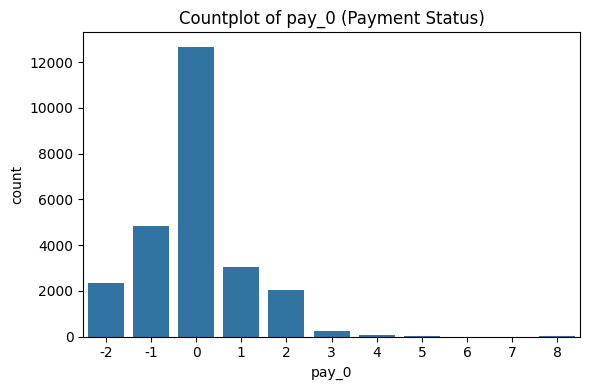

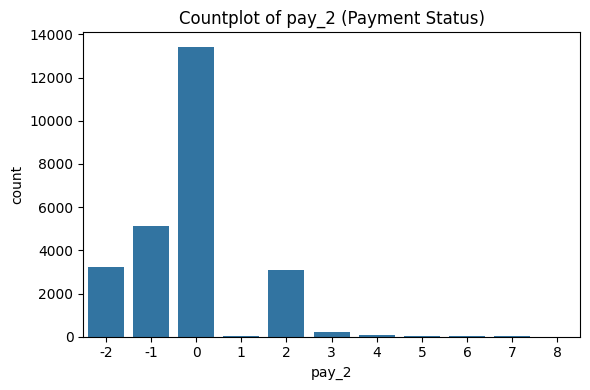

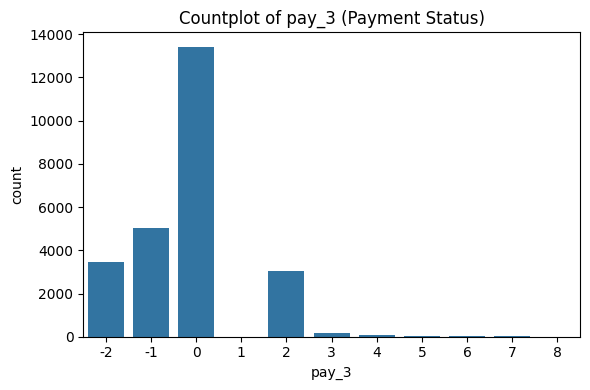

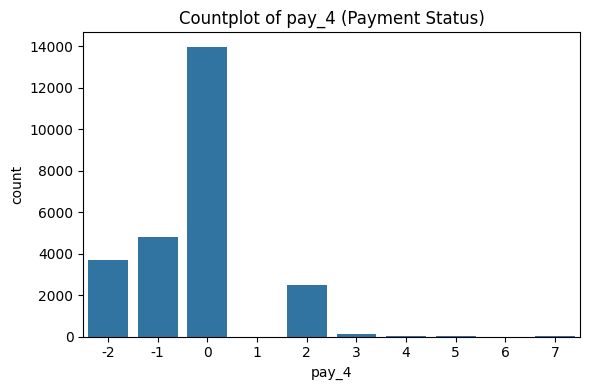

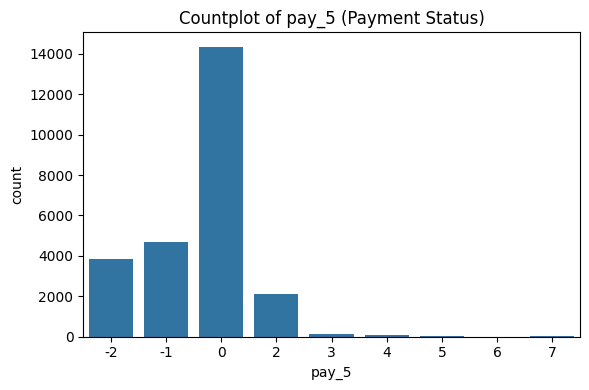

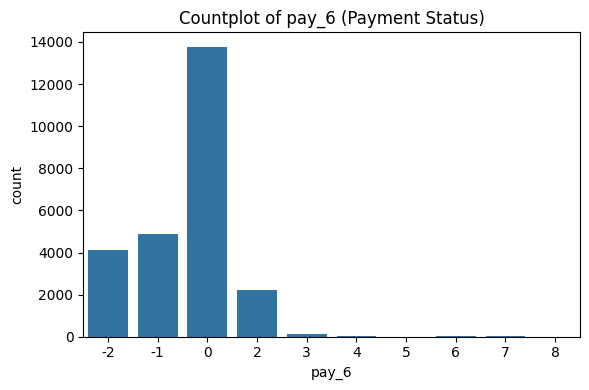

In [38]:
# Payment status columns
pay_status_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
for col in pay_status_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=train_df)
    plt.title(f'Countplot of {col} (Payment Status)')
    plt.tight_layout()
    plt.show()

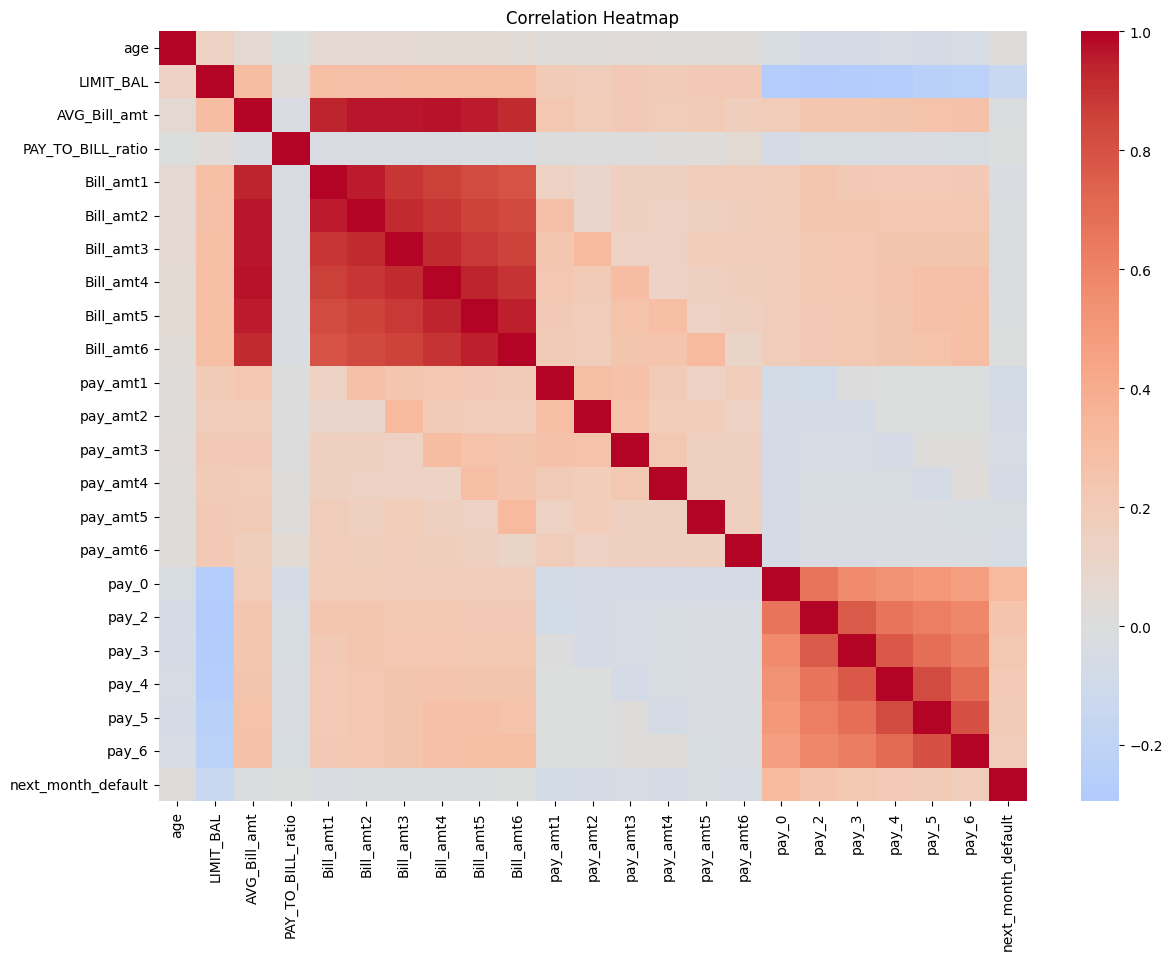

In [39]:
# --- Bivariate Analysis ---
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = train_df[numeric_cols + pay_status_cols + ['next_month_default']].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

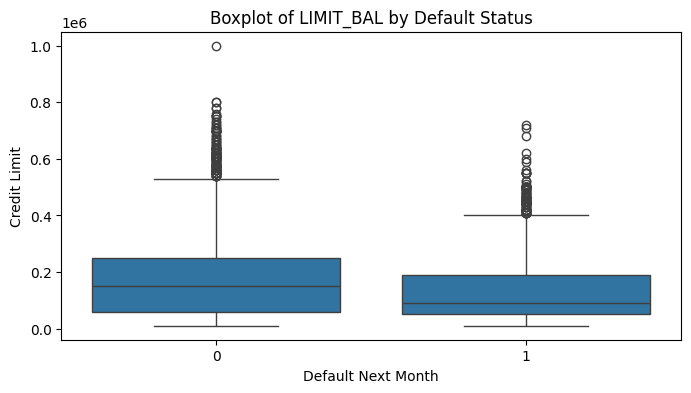

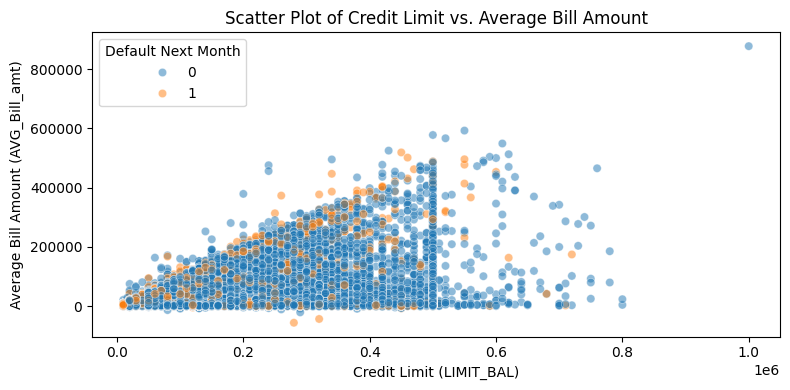

In [40]:
# LIMIT_BAL by default
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='LIMIT_BAL', data=train_df)
plt.title('Boxplot of LIMIT_BAL by Default Status')
plt.xlabel('Default Next Month')
plt.ylabel('Credit Limit')
plt.show()

# Scatter plot: LIMIT_BAL vs. AVG_Bill_amt
plt.figure(figsize=(8, 4))
sns.scatterplot(x='LIMIT_BAL', y='AVG_Bill_amt', hue='next_month_default', data=train_df, alpha=0.5)
plt.title('Scatter Plot of Credit Limit vs. Average Bill Amount')
plt.xlabel('Credit Limit (LIMIT_BAL)')
plt.ylabel('Average Bill Amount (AVG_Bill_amt)')
plt.legend(title='Default Next Month')
plt.tight_layout()
plt.show()

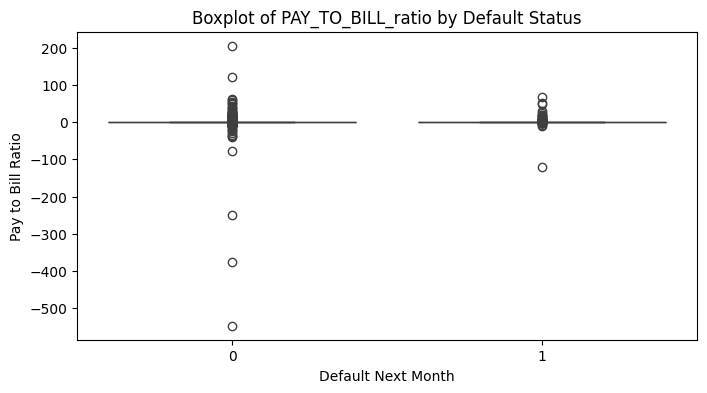

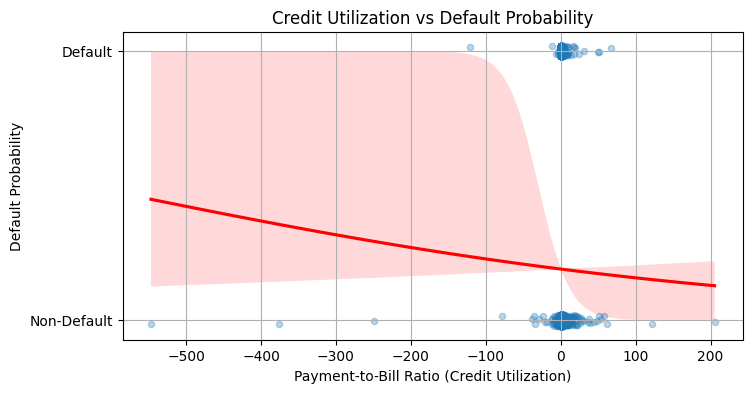

In [41]:
# PAY_TO_BILL_ratio by default
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='PAY_TO_BILL_ratio', data=train_df)
plt.title('Boxplot of PAY_TO_BILL_ratio by Default Status')
plt.xlabel('Default Next Month')
plt.ylabel('Pay to Bill Ratio')
plt.show()

# Scatter plot of credit utilization vs default probability with regression line
plt.figure(figsize=(8, 4))
sns.regplot(x='PAY_TO_BILL_ratio', y='next_month_default', data=train_df,
            logistic=True, scatter_kws={'alpha':0.3, 's':20},
            line_kws={'color':'red'}, x_jitter=0.02, y_jitter=0.02)
plt.title('Credit Utilization vs Default Probability')
plt.xlabel('Payment-to-Bill Ratio (Credit Utilization)')
plt.ylabel('Default Probability')
plt.yticks([0, 1], ['Non-Default', 'Default'])
plt.grid(True)
plt.show()

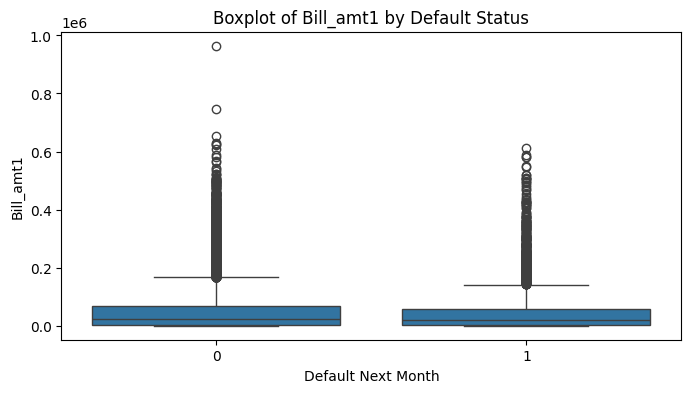

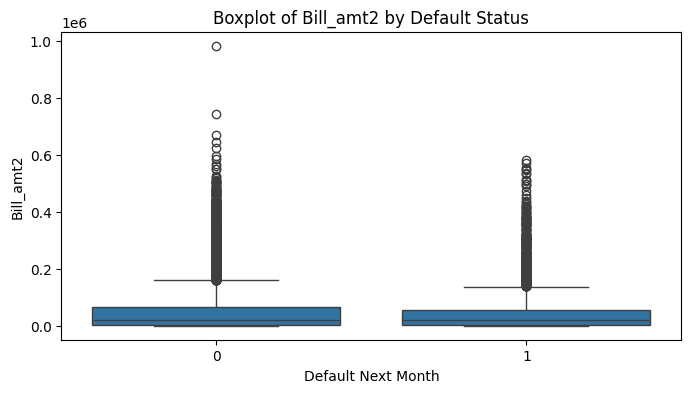

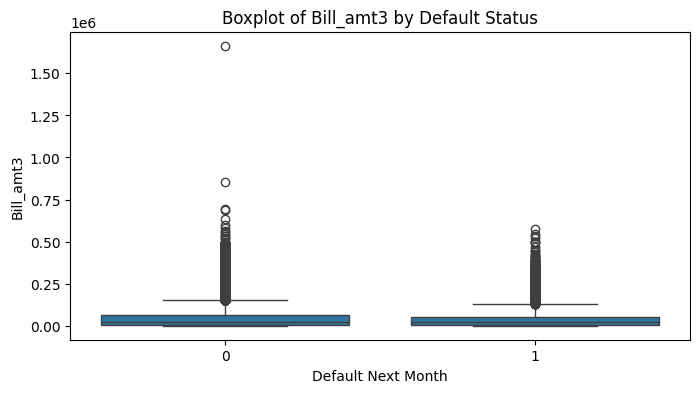

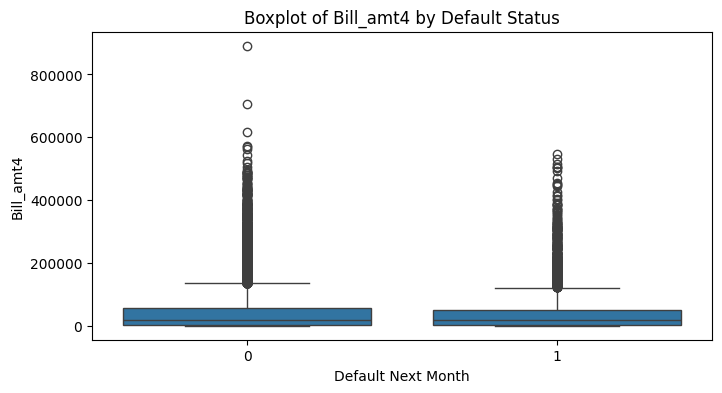

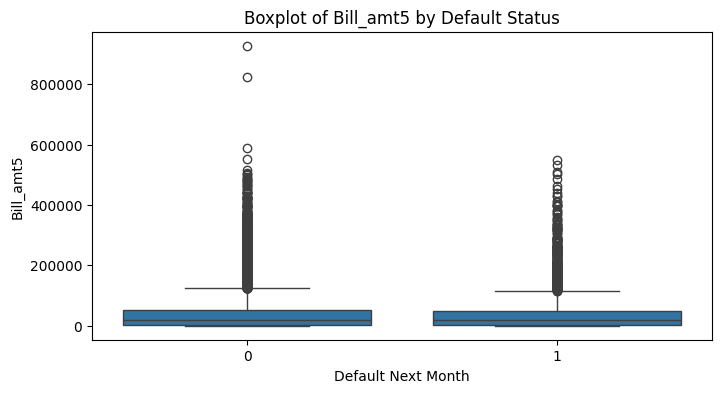

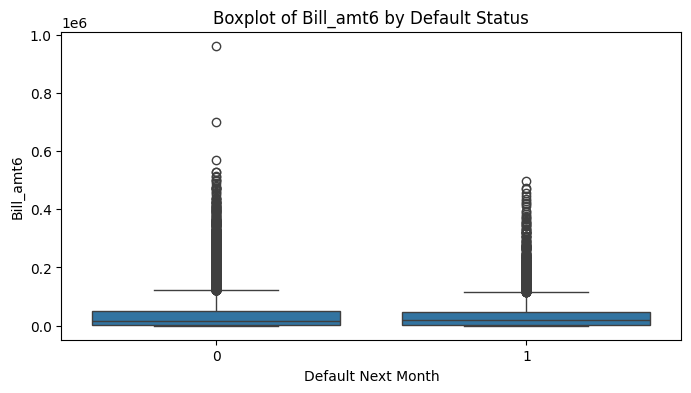

In [42]:
# Bill Amounts by default
for bill_col in ['Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6']:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='next_month_default', y=bill_col, data=train_df)
    plt.title(f'Boxplot of {bill_col} by Default Status')
    plt.xlabel('Default Next Month')
    plt.ylabel(bill_col)
    plt.show()

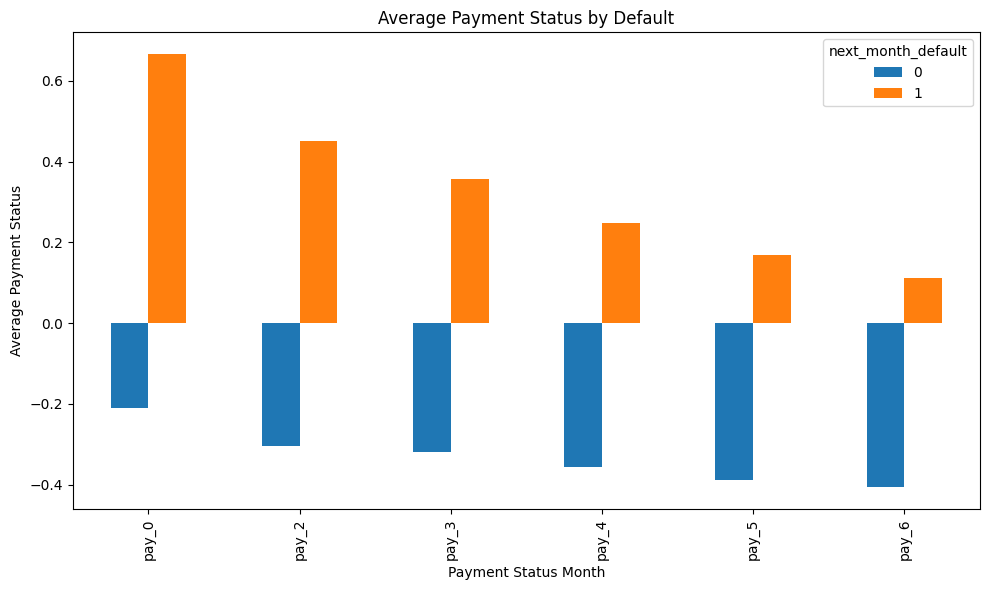

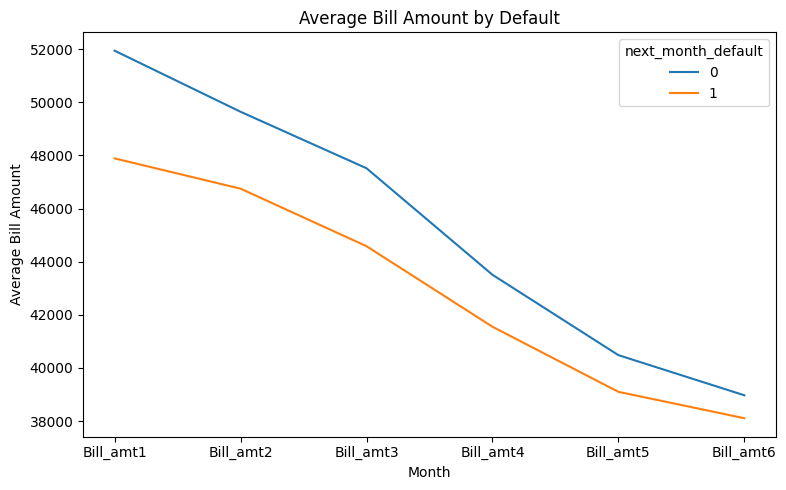

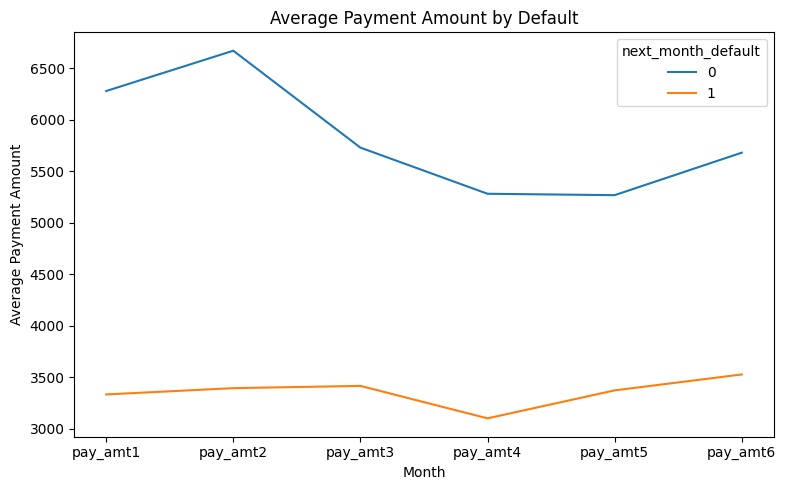

In [43]:
# --- Financial Trends & Insights ---

# Analyze payment delays: average payment status by default
avg_pay_status = train_df.groupby('next_month_default')[pay_status_cols].mean().T
avg_pay_status.plot(kind='bar', figsize=(10, 6))
plt.title('Average Payment Status by Default')
plt.ylabel('Average Payment Status')
plt.xlabel('Payment Status Month')
plt.tight_layout()
plt.show()

# Analyze bill amounts: average bill amount by default
avg_bill = train_df.groupby('next_month_default')[[f'Bill_amt{i}' for i in range(1,7)]].mean().T
avg_bill.plot(figsize=(8, 5))
plt.title('Average Bill Amount by Default')
plt.ylabel('Average Bill Amount')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

# Analyze repayment patterns: average pay amount by default
avg_pay = train_df.groupby('next_month_default')[[f'pay_amt{i}' for i in range(1,7)]].mean().T
avg_pay.plot(figsize=(8, 5))
plt.title('Average Payment Amount by Default')
plt.ylabel('Average Payment Amount')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [44]:
# Impute missing values
num_cols = numeric_cols
cat_cols = ['sex', 'marriage', 'education']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

train_df[num_cols] = num_imputer.fit_transform(train_df[num_cols])
train_df[cat_cols] = cat_imputer.fit_transform(train_df[cat_cols])
train_df[cat_cols] = train_df[cat_cols].astype(int)

# Apply same imputers to validation set
val_df[num_cols] = num_imputer.transform(val_df[num_cols])
val_df[cat_cols] = cat_imputer.transform(val_df[cat_cols])
val_df[cat_cols] = val_df[cat_cols].astype(int)

# Feature scaling
scaler = StandardScaler()
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
val_df[num_cols] = scaler.transform(val_df[num_cols])

In [45]:
# --- 1. Create New Features ---

# Credit utilization ratios
for i in range(1, 7):
    train_df[f'utilization_m{i}'] = train_df[f'Bill_amt{i}'] / (train_df['LIMIT_BAL'] + 1e-6)
    val_df[f'utilization_m{i}'] = val_df[f'Bill_amt{i}'] / (val_df['LIMIT_BAL'] + 1e-6)
train_df['avg_utilization'] = train_df[[f'utilization_m{i}' for i in range(1, 7)]].mean(axis=1)
val_df['avg_utilization'] = val_df[[f'utilization_m{i}' for i in range(1, 7)]].mean(axis=1)

# Delinquency streaks
def delinquency_streak(row):
    streak = 0
    max_streak = 0
    for col in pay_status_cols:
        if row[col] >= 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

train_df['delinq_streak'] = train_df.apply(delinquency_streak, axis=1)
val_df['delinq_streak'] = val_df.apply(delinquency_streak, axis=1)

# Repayment consistency
pay_amt_cols = [f'pay_amt{i}' for i in range(1, 7)]
train_df['pay_amt_var'] = train_df[pay_amt_cols].var(axis=1)
val_df['pay_amt_var'] = val_df[pay_amt_cols].var(axis=1)
train_df['pay_amt_mean'] = train_df[pay_amt_cols].mean(axis=1)
val_df['pay_amt_mean'] = val_df[pay_amt_cols].mean(axis=1)

# Rolling averages/trends
train_df['bill_amt_3mo_avg'] = train_df[[f'Bill_amt{i}' for i in range(1, 4)]].mean(axis=1)
val_df['bill_amt_3mo_avg'] = val_df[[f'Bill_amt{i}' for i in range(1, 4)]].mean(axis=1)
train_df['bill_amt_6mo_trend'] = train_df['Bill_amt1'] - train_df['Bill_amt6']
val_df['bill_amt_6mo_trend'] = val_df['Bill_amt1'] - val_df['Bill_amt6']

# Log-transform skewed features
for col in ['AVG_Bill_amt', 'pay_amt_var', 'pay_amt_mean', 'bill_amt_3mo_avg']:
    train_df[f'log_{col}'] = np.log1p(train_df[col])
    val_df[f'log_{col}'] = np.log1p(val_df[col])

# Interaction term
train_df['util_x_delinq'] = train_df['avg_utilization'] * train_df['delinq_streak']
val_df['util_x_delinq'] = val_df['avg_utilization'] * val_df['delinq_streak']


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


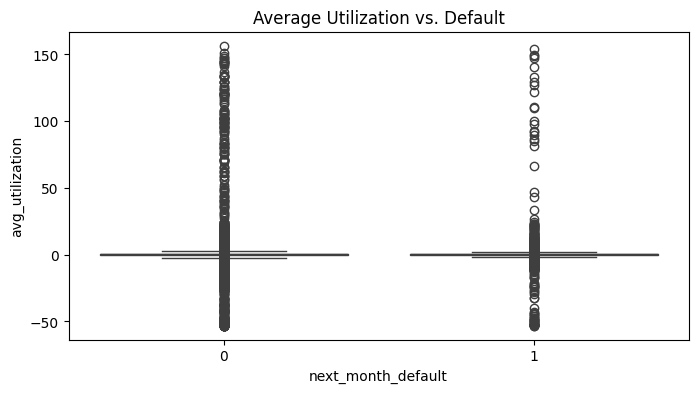

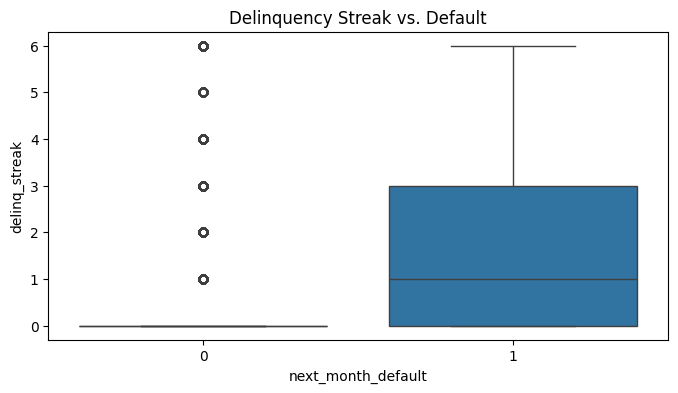

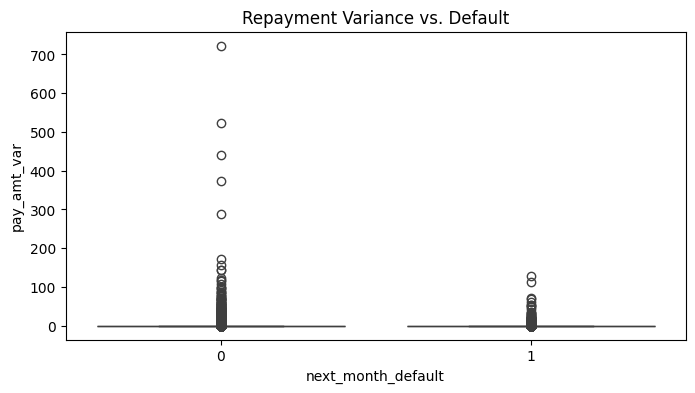

In [46]:
# Visualize Engineered Features vs. Default ---

# Utilization vs. default
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='avg_utilization', data=train_df)
plt.title('Average Utilization vs. Default')
plt.show()

# Delinquency streak vs. default
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='delinq_streak', data=train_df)
plt.title('Delinquency Streak vs. Default')
plt.show()

# Repayment variance vs. default
plt.figure(figsize=(8, 4))
sns.boxplot(x='next_month_default', y='pay_amt_var', data=train_df)
plt.title('Repayment Variance vs. Default')
plt.show()

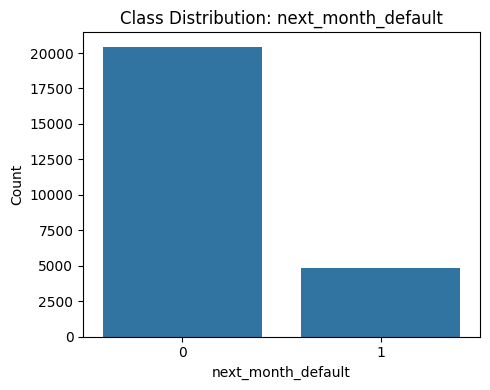

Class distribution:
next_month_default
0    0.809601
1    0.190399
Name: proportion, dtype: float64


In [47]:
# --- Class Imbalance ---

plt.figure(figsize=(5, 4))
sns.countplot(x='next_month_default', data=train_df)
plt.title('Class Distribution: next_month_default')
plt.xlabel('next_month_default')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Class distribution:')
print(train_df['next_month_default'].value_counts(normalize=True))

In [48]:
X = train_df.drop(['next_month_default', 'Customer_ID'], axis=1)
y = train_df['next_month_default']

from sklearn.impute import SimpleImputer

# Suppose X is your feature matrix before SMOTE
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print("Original class distribution:")
print(y.value_counts())
print("\nAfter SMOTE class distribution:")
print(pd.Series(y_resampled).value_counts())


Original class distribution:
next_month_default
0    20440
1     4807
Name: count, dtype: int64

After SMOTE class distribution:
next_month_default
0    20440
1    20440
Name: count, dtype: int64


In [49]:
f2_scorer = make_scorer(fbeta_score, beta=2)
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'C': [0.1, 1],
            'solver': ['liblinear'],
            'class_weight': ['balanced']

        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'max_depth': [3, 5, 7, None],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.8, 1.0]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1],
            'num_leaves': [31, 63]
        }
    }
}


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for model_name, config in models.items():
    print(f"\nTraining {model_name}...")
    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring=f2_scorer,
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    gs.fit(X_resampled, y_resampled)
    results.append({
        'model': model_name,
        'best_params': gs.best_params_,
        'best_score': gs.best_score_
    })


Training Logistic Regression...
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Training Decision Tree...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Training XGBoost...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:28:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Training LightGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 20440, number of negative: 20440
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034976 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10687
[LightGBM] [Info] Number of data points in the train set: 40880, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [51]:
results_df = pd.DataFrame(results)
print("\nModel Comparison Results:")
print(results_df.sort_values('best_score', ascending=False))

best_row = results_df.sort_values('best_score', ascending=False).iloc[0]
best_model_name = best_row['model']
best_params = best_row['best_params']

# Retrain best model on all resampled data
best_model = models[best_model_name]['model'].set_params(**best_params)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)
best_model.fit(X_train, y_train)



Model Comparison Results:
                 model                                        best_params  \
1        Decision Tree  {'criterion': 'entropy', 'max_depth': None, 'm...   
3             LightGBM  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   
2              XGBoost  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...   
0  Logistic Regression  {'C': 1, 'class_weight': 'balanced', 'solver':...   

   best_score  
1    0.790230  
3    0.783593  
2    0.783054  
0    0.636109  


DecisionTreeClassifier(criterion='entropy')

In [52]:
# Predict probabilities
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

def find_optimal_threshold(y_true, y_proba, metric='f2'):
    thresholds = np.arange(0.1, 0.9, 0.01)
    scores = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        if metric == 'f2':
            score = fbeta_score(y_true, y_pred, beta=2)
        elif metric == 'f1':
            score = f1_score(y_true, y_pred)
        elif metric == 'precision':
            score = precision_score(y_true, y_pred)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred)
        scores.append(score)
    optimal_idx = np.argmax(scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_score = scores[optimal_idx]
    return optimal_threshold, optimal_score

optimal_threshold, optimal_f2 = find_optimal_threshold(y_test, y_pred_proba, 'f2')
print(f"Optimal Threshold: {optimal_threshold:.3f}, Optimal F2-Score: {optimal_f2:.4f}")

# Evaluate at optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_optimal, target_names=['No Default', 'Default']))


Optimal Threshold: 0.100, Optimal F2-Score: 0.8316
              precision    recall  f1-score   support

  No Default       0.83      0.81      0.82      4088
     Default       0.81      0.84      0.82      4088

    accuracy                           0.82      8176
   macro avg       0.82      0.82      0.82      8176
weighted avg       0.82      0.82      0.82      8176



In [55]:
# Prepare validation features
val_features = val_df.drop(['Customer_ID'], axis=1)
val_pred_proba = best_model.predict_proba(val_features)[:, 1]
val_pred = (val_pred_proba >= optimal_threshold).astype(int)

submission = pd.DataFrame({
    'Customer': val_df['Customer_ID'],
    'next_month_default': val_pred
})

submission.to_csv('submission_<22322002>.csv', index=False)
print("Submission file created!")


Submission file created!


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
